In [453]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
from scipy.integrate import odeint
from numba import jit

In [2]:
"""
# nominal CoSMO type
n_strains = 2
n_resources = 3

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[0,1] = 2
c[1,2] = 2

l = np.zeros((n_strains,n_resources))
degree = 1
l[0,0] = 1*degree
l[1,0] = 1*degree

#nutrient "quality"
w = np.ones(n_resources)

#chemostat feeding
k = np.zeros(n_resources)
k[0] = 3

#chemostat dilution rate
r = np.ones(n_resources)*1
#r = np.array([1,0.2,0.2])

#death rate
m = np.ones(n_strains)*0.9

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,2,0] = 1
CF_array[1,1,0] = 1

#print(c)

#print(CF_array)

ratios = np.array([0.49,0.51])

D = np.array([0.01,0.01]) #diffusion constant for cells

H = np.array([100,1,1]) #diffusion constants for resources
"""

'\n# nominal CoSMO type\nn_strains = 2\nn_resources = 3\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,0] = 2\nc[0,1] = 2\nc[1,2] = 2\n\nl = np.zeros((n_strains,n_resources))\ndegree = 1\nl[0,0] = 1*degree\nl[1,0] = 1*degree\n\n#nutrient "quality"\nw = np.ones(n_resources)\n\n#chemostat feeding\nk = np.zeros(n_resources)\nk[0] = 3\n\n#chemostat dilution rate\nr = np.ones(n_resources)*1\n#r = np.array([1,0.2,0.2])\n\n#death rate\nm = np.ones(n_strains)*0.9\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[0,2,0] = 1\nCF_array[1,1,0] = 1\n\n#print(c)\n\n#print(CF_array)\n\nratios = np.array([0.49,0.51])\n\nD = np.array([0.01,0.01]) #diffusion constant for cells\n\nH = np.array([100,1,1]) #diffusion constants for resources\n'

In [3]:
"""
# circle, glucose competition
n_strains = 3
n_resources = 4

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[2,0] = 2
c[0,3] = 2
c[1,1] = 2
c[2,2] = 2

l = np.zeros((n_strains,n_resources))
l[0,0] = 1
l[1,0] = 1
l[2,0] = 1

w = np.array([1,1,1,1])

k = np.array([1,0,0,0])

r = np.ones(n_resources)*0.3

m = np.ones(n_strains)*0.7

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,1,0] = 1
CF_array[1,2,0] = 1
CF_array[2,3,0] = 1


#print(c)
#print(CF_array)

ratios = np.array([0.3,0.5,0.2])

D = np.array([0.01,0.01,0.01])*0 #diffusion constant for cells

H = np.array([10,1,1,100]) #diffusion constants for resources
"""

'\n# circle, glucose competition\nn_strains = 3\nn_resources = 4\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,0] = 2\nc[2,0] = 2\nc[0,3] = 2\nc[1,1] = 2\nc[2,2] = 2\n\nl = np.zeros((n_strains,n_resources))\nl[0,0] = 1\nl[1,0] = 1\nl[2,0] = 1\n\nw = np.array([1,1,1,1])\n\nk = np.array([1,0,0,0])\n\nr = np.ones(n_resources)*0.3\n\nm = np.ones(n_strains)*0.7\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[0,1,0] = 1\nCF_array[1,2,0] = 1\nCF_array[2,3,0] = 1\n\n\n#print(c)\n#print(CF_array)\n\nratios = np.array([0.3,0.5,0.2])\n\nD = np.array([0.01,0.01,0.01])*0 #diffusion constant for cells\n\nH = np.array([10,1,1,100]) #diffusion constants for resources\n'

In [ ]:
"""
# strict circle, one focal cell
n_strains = 3
n_resources = 4

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
#c[1,0] = 2
#c[2,0] = 2
c[0,3] = 2
c[1,1] = 2
c[2,2] = 2

l = np.zeros((n_strains,n_resources))
l[0,0] = 1
l[1,1] = 0.5
l[2,2] = 0.5

w = np.array([1,1,1,1])

k = np.array([2,0,0,0])

r = np.ones(n_resources)*0.3

m = np.ones(n_strains)*0.3

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,1,0] = 1
CF_array[1,2,1] = 1
CF_array[2,3,2] = 1


#print(c)
#print(CF_array)

ratios = np.array([0.3,0.5,0.2])

D = np.array([0.01,0.01,0.01])*0 #diffusion constant for cells

H = np.array([100,1,1,10]) #diffusion constants for resources"
"""

In [5]:
"""
# nominal CoSMO hinge
n_strains = 3
n_resources = 5

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[2,0] = 2
c[0,3] = 0.5
c[0,4] = 2
c[1,1] = 2
c[2,2] = 2

l = np.zeros((n_strains,n_resources))
l[0,0] = 1
l[1,0] = 1
l[2,0] = 1

w = np.array([1,1,1,1,1])

k = np.zeros(n_resources)
k[0] = 1

r = np.ones(n_resources)*0.3

m = np.ones(n_strains)*0.7

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,1,0] = 1
CF_array[0,2,0] = 1
CF_array[1,3,0] = 0
CF_array[2,4,0] = 1


print(c)
print(CF_array)

ratios = np.array([0.3,0.5,0.2])

D = np.array([0.0001,0.0001,0.0001]) #diffusion constant for cells

H = np.array([1000,100,1,1,1,1]) #diffusion constants for resources
"""

'\n# nominal CoSMO hinge\nn_strains = 3\nn_resources = 5\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,0] = 2\nc[2,0] = 2\nc[0,3] = 0.5\nc[0,4] = 2\nc[1,1] = 2\nc[2,2] = 2\n\nl = np.zeros((n_strains,n_resources))\nl[0,0] = 1\nl[1,0] = 1\nl[2,0] = 1\n\nw = np.array([1,1,1,1,1])\n\nk = np.zeros(n_resources)\nk[0] = 1\n\nr = np.ones(n_resources)*0.3\n\nm = np.ones(n_strains)*0.7\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[0,1,0] = 1\nCF_array[0,2,0] = 1\nCF_array[1,3,0] = 0\nCF_array[2,4,0] = 1\n\n\nprint(c)\nprint(CF_array)\n\nratios = np.array([0.3,0.5,0.2])\n\nD = np.array([0.0001,0.0001,0.0001]) #diffusion constant for cells\n\nH = np.array([1000,100,1,1,1,1]) #diffusion constants for resources\n'

In [ ]:
"""
# 2 crossfeeding pairs
n_strains = 4
n_resources = 7

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[2,0] = 2
c[3,0] = 2
c[0,2] = 2
c[0,6] = 1
c[1,1] = 2
c[2,3] = 2
c[3,4] = 2
c[3,5] = 1

l = np.zeros((n_strains,n_resources))
l[0,0] = 1
l[1,0] = 1
l[2,0] = 1
l[3,0] = 1

w = np.ones(n_resources)

k = np.zeros(n_resources)
k[0] = 5

r = np.ones(n_resources)*0.3

m = np.ones(n_strains)*0.7

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,1,0] = 0.8
CF_array[0,5,0] = 0.2
CF_array[1,2,0] = 1
CF_array[2,4,0] = 1
CF_array[3,3,0] = 0.8
CF_array[3,6,0] = 0.2


#print(c)
#print(CF_array)

ratios = np.array([0.25,0.25,0.25,0.25])

D = np.array([0.0001,0.0001,0.0001,0.0001]) #diffusion constant for cells

H = np.array([0,1,1,1,1,10,10]) #diffusion constants for resources
"""

In [ ]:
"""
# 2 crossfeeding pairs
n_strains = 4
n_resources = 7

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[2,0] = 2
c[3,0] = 2
c[0,2] = 2
c[0,6] = 1
c[1,1] = 2
c[2,3] = 2
c[3,4] = 2
c[3,5] = 1

l = np.zeros((n_strains,n_resources))
l[0,0] = 1
l[1,0] = 1
l[2,0] = 1
l[3,0] = 1

w = np.ones(n_resources)

k = np.zeros(n_resources)
k[0] = 5

r = np.ones(n_resources)*0.3

m = np.ones(n_strains)*0.7

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,1,0] = 0.8
CF_array[0,5,0] = 0.2
CF_array[1,2,0] = 1
CF_array[2,4,0] = 1
CF_array[3,3,0] = 0.8
CF_array[3,6,0] = 0.2


#print(c)
#print(CF_array)

ratios = np.array([0.25,0.25,0.25,0.25])

D = np.array([0.0001,0.0001,0.0001,0.0001]) #diffusion constant for cells

H = np.array([100,1,1,1,1,10,10]) #diffusion constants for resources
"""

In [540]:


# len 3 linear chain
n_strains = 3
n_resources = 4

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,1] = 2
c[2,2] = 2


l = np.zeros((n_strains,n_resources))
l[0,0] = 0.8
l[1,1] = 0.5
l[2,2] = 0



w = np.ones(n_resources)

k = np.ones(n_resources)
k[0] = 1

r = np.ones(n_resources)*0.01

m = np.ones(n_strains)*0.1

tau = 1

B = 1/tau*m

ratios = np.array([0.3,0.5,0.2])

CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,1,0] = 1
CF_array[1,2,1] = 1
CF_array[2,3,2] = 1

#print(c)
#print(CF_array)

D = np.ones(n_strains)*0.001#diffusion constant for cells
H = np.array([1,1,1,1]) #diffusion constants for resources"


In [541]:
#PDE next!!!

In [542]:
# Combine initial conditions into a single vector
def flatten_state(N, R):
    return np.concatenate([N.flatten(), R.flatten()])


def unflatten_state(y):
    N = y[:(S * nx)].reshape(S, nx)
    R = y[(S * nx):].reshape(M, nx)
    return N, R


def unflatten_state_end(y, S, M, nx):
    """
    Unflatten the state vector into two separate lists N and R.

    Parameters:
    y (list): Flattened state vector.
    S (int): Number of rows for N.
    M (int): Number of rows for R.
    nx (int): Number of columns for both N and R.

    Returns:
    tuple: Two lists N and R.
    """
    N = []
    R = []
    
    for i in range(S):
        N.append(y[i * nx:(i + 1) * nx])
    
    for i in range(M):
        R.append(y[(S * nx) + i * nx:(S * nx) + (i + 1) * nx])
    
    return N, R

# Define the PDE system as a set of ODEs using finite differences for spatial derivatives
def pde_system_one_resource_boundary(y, t):
    N, R = unflatten_state(y)
    
    # Initialize derivatives
    dNdt = np.zeros((S, nx))
    dRdt = np.zeros((M, nx))
    
    # Calculate spatial derivatives using finite differences no flux boundary on the right, absorbing on the left 
    def laplacian(u):
        length = len(u)
        L = np.zeros(length)
        for ii in range(length):
            if ii == 0:
                u_left = 0 #absorbant boundary condition
                u_right = u[ii + 1]
            elif ii == length - 1:
                u_left = u[ii - 1]
                u_right = 0 #absorbant boundary condition
                #u_right = u[ii] #one sided gradient
            else:
                u_left = u[ii - 1]
                u_right = u[(ii + 1) % length]
            L[ii] = (u_left - 2*u[ii] + u_right) / (dx**2)
        return L
    
    def feed_laplacian(u):
        length = len(u)
        L = np.zeros(length)
        for ii in range(length):
            if ii == 0:
                u_left = kappa[0] #symmetric feed from left
                u_right = u[ii + 1]
            elif ii == length - 1:
                u_left = u[ii - 1]
                #u_right = 0 #absorbant boundary condition
                u_right = kappa[0] #feed nutrient from the right
            else:
                u_left = u[ii - 1]
                u_right = u[(ii + 1) % length]
            L[ii] = (u_left - 2*u[ii] + u_right) / (dx**2)
        return L
        
    
    # Calculate diffusion terms
    for i in range(S):
        #print(np.shape(N[i, :]))
        dNdt[i] += D_N[i] * laplacian(N[i, :])
    
    for alpha in range(M):
        if alpha == 0:
            dRdt[alpha] += D_R[alpha] * feed_laplacian(R[alpha, :])
        else:
            dRdt[alpha] += D_R[alpha] * laplacian(R[alpha, :])
    
    # Calculate reaction terms for species
    for i in range(S):
        growth_term = 0
        for alpha in range(M):
            #density dependent growth
            biomass_vector = np.sum(N, axis=0)
            growth_term += (1 - l[i, alpha]) * w[alpha] * c_i_alpha[i, alpha] * R[alpha] * (1 - biomass_vector/10) #setting the growth penalty at 10
        dNdt[i] += N[i] * (growth_term - m[i])
    
    # Calculate reaction terms for resources
    for alpha in range(M):
        
        #only allow resource entrance from the right
        #dRdt[alpha,-1] = kappa[alpha]*10

        # Resource decay
        dRdt[alpha] += - rho[alpha] * R[alpha]
        
        # Consumption by species
        for i in range(S):
            dRdt[alpha] -= N[i] * c_i_alpha[i, alpha] * R[alpha]
        
        # Conversion from other resources
        for i in range(S):
            for beta in range(M):
                if beta != alpha:
                    dRdt[alpha] += N[i] * D_i_alpha_beta[i, alpha, beta] * l[i, beta] * (w[beta] / w[alpha]) * c_i_alpha[i, beta] * R[beta]

    return flatten_state(dNdt, dRdt)


In [543]:
Nss = np.ones(n_strains)*0.1
Rss = np.ones(n_resources)*0.1

In [544]:
#PDE properties
L = 25  # Spatial domain length
dx = 0.1
nx = int(L/dx)  # Number of spatial points
x = np.linspace(0, L, nx)  # Spatial grid

# Time settings
t_final = 1000
dt = 0.001
nt = int(t_final/dt)
t = np.linspace(0, t_final, nt)

In [545]:
#convert between ODE and PDE function variables
S = n_strains
M = n_resources
D_i_alpha_beta = CF_array
c_i_alpha = c
rho = r
D_N = D
D_R = H
kappa = k

In [546]:
#initial conditions
mag = 0.01

N_init = np.zeros((S, nx))  # Both species at uniform density Nss
R_init = np.zeros((M, nx))


for xx in range(nx):
    for ss in range(n_strains):
        N_init[ss,xx] = Nss[ss] + mag*np.random.normal()

    for rr in range(n_resources):
        R_init[rr,xx] = Rss[rr] + mag*np.random.normal()


In [ ]:
# Solve the PDE system
initial_state = flatten_state(N_init, R_init)
solution = odeint(pde_system_one_resource_boundary, initial_state, t)

: 

: 

: 

: 

In [ ]:
# Extract solutions at different time points
N_solutions = []
R_solutions = []
tm = []

stride = 1000

for i in range(int(len(t)/stride)):

    time = t[i*stride]
    tm.append(time)

    N, R = unflatten_state_end(solution[i*stride],S,M,nx)
    N_solutions.append(N.copy())
    R_solutions.append(R.copy())

# Convert to numpy arrays for easier indexing
N_solutions = np.array(N_solutions)
R_solutions = np.array(R_solutions)

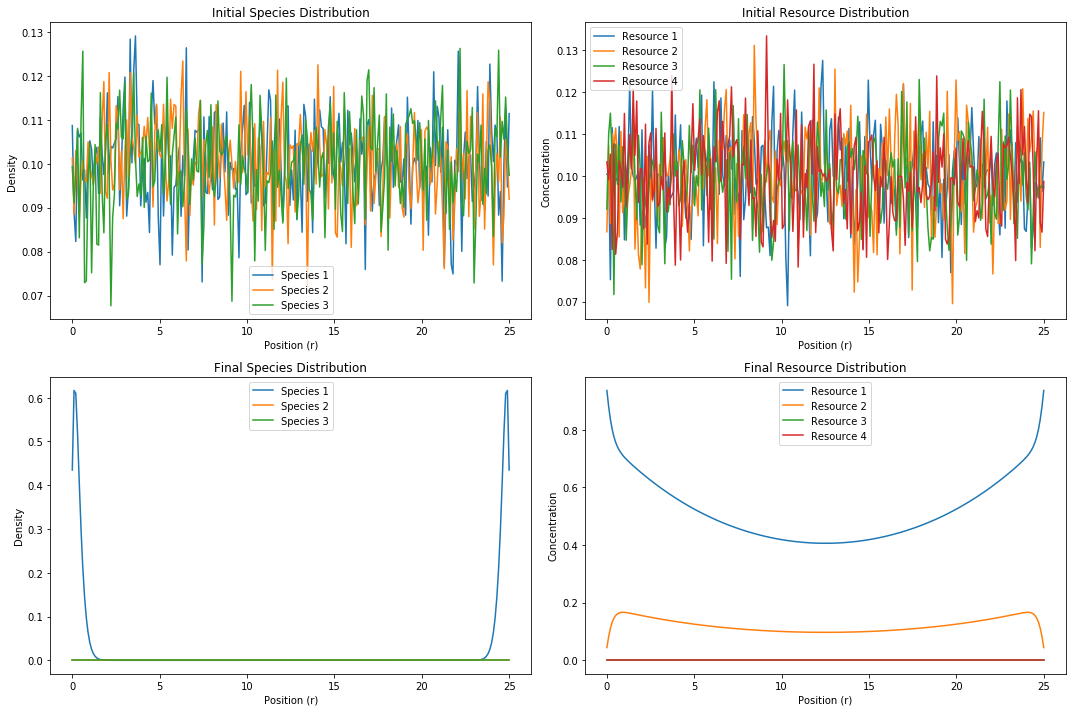

In [ ]:
# Plot initial and final states
plt.figure(figsize=(15, 10))

# Plot initial state
plt.subplot(2, 2, 1)
for i in range(S):
    plt.plot(x, N_solutions[0, i], label=f'Species {i+1}')
plt.title('Initial Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 2, 2)
for alpha in range(M):
    plt.plot(x, R_solutions[0, alpha], label=f'Resource {alpha+1}')
plt.title('Initial Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Concentration')
plt.legend()

# Plot final state
plt.subplot(2, 2, 3)
for i in range(S):
    plt.plot(x, N_solutions[-1, i], label=f'Species {i+1}')
plt.title('Final Species Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Density')
plt.legend()

plt.subplot(2, 2, 4)
for alpha in range(M):
    plt.plot(x, R_solutions[-1, alpha], label=f'Resource {alpha+1}')
plt.title('Final Resource Distribution')
plt.xlabel('Position (r)')
plt.ylabel('Concentration')
plt.legend()

plt.tight_layout()
#plt.savefig('1D_pde_solution_190325.png')
plt.show()

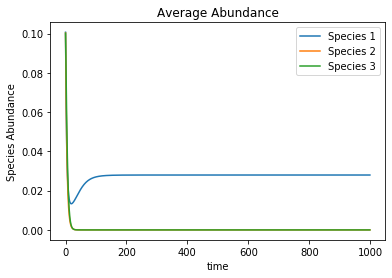

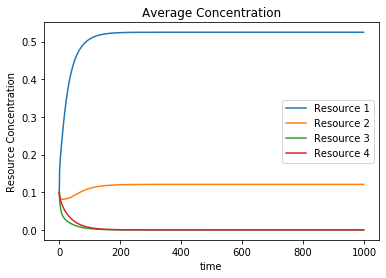

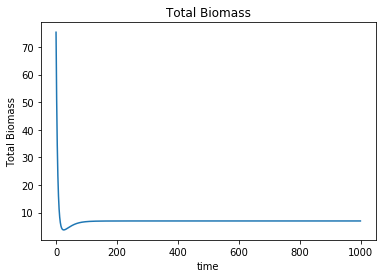

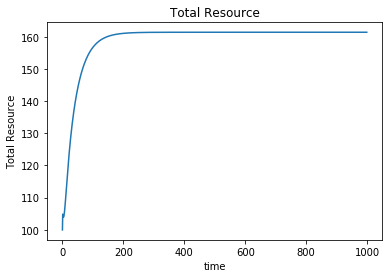

In [ ]:
colors = ['k','r']
#stride = 1000
for i in range(S):
    plt.plot(tm, np.mean(N_solutions[:, i],axis = -1), label=f'Species {i+1}')
plt.title('Average Abundance')
plt.xlabel('time')
plt.ylabel('Species Abundance')
plt.legend()
plt.show()

stride = 1000
for i in range(M):
    plt.plot(tm, np.mean(R_solutions[:, i],axis = -1), label=f'Resource {i+1}')
plt.title('Average Concentration')
plt.xlabel('time')
plt.ylabel('Resource Concentration')
plt.legend()
plt.show()

#total biomass
plt.plot(tm, np.sum(N_solutions, axis=(1, 2)))
plt.title('Total Biomass')
plt.xlabel('time')
plt.ylabel('Total Biomass')
plt.show()

#total resource
plt.plot(tm, np.sum(R_solutions, axis=(1, 2)))
plt.title('Total Resource')
plt.xlabel('time')
plt.ylabel('Total Resource')
plt.show()
